# CNN training dynamics and controlled ablations

This notebook studies three engineering questions: Which settings improve convergence and stability? Which history patterns support an underfitting or overfitting diagnosis? Do training parameters or model parameters have the larger robust effect and therefore deserve attention first?

`train` is used to fit parameters. The fixed `validate` fold is called **tune** here and controls early stopping, diagnostics, and model selection. **The test fold is never loaded in this notebook.** Tune macro-F1 is the primary metric because the dose classes are imbalanced.

## Contents

| Section | Question |
|---|---|
| [1. Experimental design](#experimental-design) | How are folds, controls, and artifacts fixed? |
| [2. Compact CNN](#compact-cnn) | What does a constrained capacity anchor learn? |
| [3. Baseline CNN](#baseline-cnn) | What does a moderate-capacity reference learn? |
| [4. Wide CNN](#wide-cnn) | Does convolutional capacity alone help? |
| [5. Capacity comparison](#capacity-comparison) | How do performance and histories differ? |
| [6. Training ablations](#training-ablations) | Which optimization choices matter? |
| [7. Model ablations](#model-ablations) | Which architectural parameters matter? |
| [8. Stability and fit diagnosis](#stability-diagnosis) | Are gains stable, converged, underfit, or overfit? |
| [9. Conclusions](#conclusions) | What should be optimized first? |

<a id="experimental-design"></a>
## 1. Experimental design and fixed folds

The first comparison is an explicit **diagnostic stress test**: Compact is deliberately capacity-limited, Baseline remains moderately regularized, and Wide is deliberately over-parameterized and weakly regularized. It demonstrates recognizable fit regimes and is not a fair architecture leaderboard. The previous controlled settings are retained in code for reproducibility.

In [20]:
from dataclasses import replace
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from pytorch_timecourse_classification.analysis import (
    analyze_training_history, evaluate_classifier,
    plot_ablation_diagnostics, plot_history_comparison,
)
from pytorch_timecourse_classification.artifacts import artifact_dir_for
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.experiments import (
    create_model, fit_model, save_and_verify_experiment,
)
from pytorch_timecourse_classification.models.cnn import CNNClassifier
from pytorch_timecourse_classification.training import TrainingConfig
from pytorch_timecourse_classification.tuning import (
    AblationSpec, add_paired_reference_deltas, run_ablations,
    save_ablation_study, summarize_ablations,
)

In [46]:
RANDOM_SEED = 42
ABLATION_SEEDS = (42, 43, 44)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_fold, tune_fold, preprocessor = load_training_folds()

PREVIOUS_SHARED_TRAINING_CONFIG = TrainingConfig(
    epochs=200, batch_size=256, learning_rate=6e-4, weight_decay=5e-4,
    scheduler_strategy="step", scheduler_step_size=15,
    learning_rate_decay=0.75, patience=20,
    class_balance_strategy="weighted_loss", gradient_clip_norm=1.0,
)
ABLATION_REFERENCE_TRAINING_CONFIG = PREVIOUS_SHARED_TRAINING_CONFIG
BASELINE_MODEL_CONFIG = {
    "channels": (16, 32, 64),
    "kernel_sizes": (9, 5, 3),
    "dilations": (1, 1, 1),
    "pool_size": 2,
    "hidden_dim": 32,
    "dropout": 0.30,
    "residual": False,
}
PREVIOUS_CAPACITY_CONFIGS = {
    "compact": {
        **BASELINE_MODEL_CONFIG, "channels": (8, 16),
        "kernel_sizes": (9, 5), "dilations": (1, 1),
    },
    "baseline": dict(BASELINE_MODEL_CONFIG),
    "wide": {
        **BASELINE_MODEL_CONFIG, "channels": (32, 64, 128, 256),
        "kernel_sizes": (9, 5, 3, 3),
        "dilations": (1, 1, 1, 1), "hidden_dim": 64,
    },
}

build_model = partial(
    create_model, CNNClassifier,
    input_length=train_fold.features.shape[-1],
    num_classes=len(preprocessor.class_names),
    random_seed=RANDOM_SEED,
)
fit = partial(
    fit_model, training_fold=train_fold, tuning_fold=tune_fold, device=device,
)
evaluate_tune = partial(
    evaluate_classifier, fold=tune_fold,
    class_names=preprocessor.class_names, device=device,
)
save_and_verify = partial(
    save_and_verify_experiment, preprocessor=preprocessor,
    training_fold=train_fold, tuning_fold=tune_fold, device=device,
)

print(f"train: {tuple(train_fold.features.shape)}")
print(f" tune: {tuple(tune_fold.features.shape)}")
print(f"classes: {preprocessor.class_names}")
print(f"device: {device}")

train: (2790, 1, 289)
 tune: (349, 1, 289)
classes: ('0pM', '1pM', '2.5pM', '5pM', '25pM', '100pM')
device: cuda


<a id="compact-cnn"></a>
## 2. Compact CNN

The compact stress-test model has only 278 trainable parameters, two very narrow blocks, aggressive pooling, and a tiny head. It is trained long enough to distinguish a persistently low train score from merely stopping too early. Low train-eval and tune performance together indicate underfitting.

### 2.1 Model generation

In [47]:
compact_model_config = {
    **BASELINE_MODEL_CONFIG,
    "channels": (8, 16),
    "kernel_sizes": (5, 3),
    "dilations": (1, 1),
    "pool_size": 4,
    "hidden_dim": 8,
}
compact_training_config = replace(
    PREVIOUS_SHARED_TRAINING_CONFIG, epochs=180, patience=30,
)
compact_model, compact_parameter_count = build_model(**compact_model_config)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (8, 16), 'kernel_sizes': (5, 3), 'dilations': (1, 1), 'pool_size': 4, 'hidden_dim': 8, 'dropout': 0.3, 'residual': False}
trainable parameters: 686


### 2.2 Training

In [48]:
compact_history = fit(compact_model, compact_training_config)

training_config: TrainingConfig(epochs=180, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.75, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=30, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.88675, validation loss 1.81172, train accuracy 24.2%, validation accuracy 22.3%
epoch   5: train loss 1.70489, validation loss 1.72665, train accuracy 28.7%, validation accuracy 23.5%
epoch  10: train loss 1.61177, validation loss 1.62449, train accuracy 30.2%, validation accuracy 32.1%
epoch  15: train loss 1.51033, validation loss 1.53854, train accuracy 28.1%, validation accuracy 32.1%
epoch  20: train loss 1.45171, validation loss 1.48499, train accuracy 28.1%, validation accuracy 34.7%
epoch  25: train loss 1.40584, validation loss 1.44246, train accuracy 30.0%, validation accuracy 37.2%
epoch  30: train

### 2.3 History analysis

Low train and tune macro-F1 together support an underfitting diagnosis. A small gap alone does not demonstrate generalization.

{'epochs_run': 180, 'best_epoch': 180, 'training_loss': 1.2780484687470193, 'tune_loss': 1.2654801999941938, 'training_accuracy': 0.3727598566308244, 'tune_accuracy': 0.48424068767908307, 'training_macro_f1': 0.3693186559461916, 'tune_macro_f1': 0.4042480655993865, 'accuracy_gap': -0.11148083104825868, 'macro_f1_gap': -0.034929409653194854}
Both train and tune macro-F1 are low: inspect for underfitting.


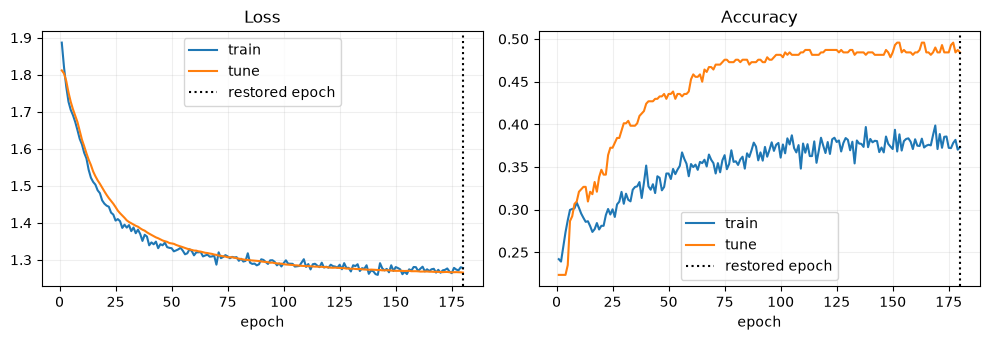

In [49]:
compact_history_summary = analyze_training_history(compact_history, diagnose_fit=True)

### 2.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.00      0.00      0.00        36
         1pM       0.52      0.86      0.65        78
       2.5pM       0.49      0.47      0.48        66
         5pM       0.42      0.34      0.38        62
        25pM       0.55      0.24      0.33        72
       100pM       0.43      0.94      0.59        35

    accuracy                           0.48       349
   macro avg       0.40      0.47      0.40       349
weighted avg       0.44      0.48      0.43       349



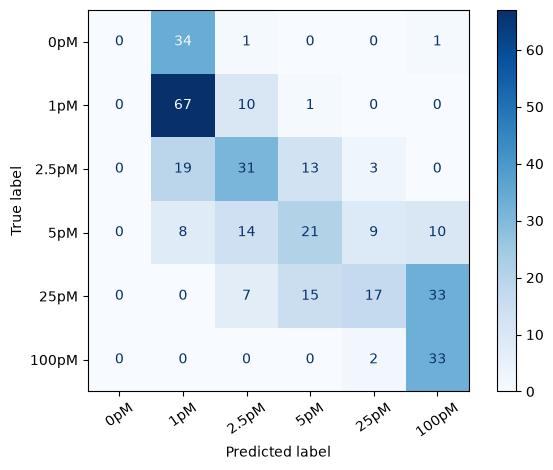

In [50]:
compact_tune_metrics = evaluate_tune(compact_model)

### 2.5 Saving artifacts

In [51]:
compact_reloaded, compact_artifacts = save_and_verify("cnn_compact", compact_model, compact_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/metadata.json'))
reloaded cnn at best epoch 180


<a id="baseline-cnn"></a>
## 3. Baseline CNN

The baseline remains the moderate middle regime. Its architecture and regularization are unchanged; only the maximum budget is extended so its history has enough room to converge. The separate systematic ablations still use the original 120-epoch reference.

### 3.1 Model generation

In [54]:
baseline_training_config = replace(
    PREVIOUS_SHARED_TRAINING_CONFIG, patience=25,
)
baseline_model, baseline_parameter_count = build_model(**BASELINE_MODEL_CONFIG)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (16, 32, 64), 'kernel_sizes': (9, 5, 3), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 32, 'dropout': 0.3, 'residual': False}
trainable parameters: 11,462


### 3.2 Training

In [55]:
baseline_history = fit(baseline_model, baseline_training_config)

training_config: TrainingConfig(epochs=200, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.75, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=25, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.78757, validation loss 1.80352, train accuracy 20.5%, validation accuracy 6.6%
epoch   5: train loss 1.50020, validation loss 1.56994, train accuracy 28.1%, validation accuracy 21.5%
epoch  10: train loss 1.28996, validation loss 1.34731, train accuracy 39.1%, validation accuracy 37.0%
epoch  15: train loss 1.18550, validation loss 1.23284, train accuracy 44.0%, validation accuracy 42.4%
epoch  20: train loss 1.15387, validation loss 1.19403, train accuracy 44.9%, validation accuracy 47.6%
epoch  25: train loss 1.12986, validation loss 1.16301, train accuracy 46.5%, validation accuracy 47.9%
epoch  30: train 

### 3.3 History analysis

The reference should reach useful train performance without a large post-best tune-loss increase. This history defines the baseline for later paired comparisons.

{'epochs_run': 200, 'best_epoch': 197, 'training_loss': 1.0279706496491654, 'tune_loss': 1.0413634169067558, 'training_accuracy': 0.524731182795699, 'tune_accuracy': 0.5558739255014327, 'training_macro_f1': 0.530281467337615, 'tune_macro_f1': 0.5635257015899979, 'accuracy_gap': -0.031142742705733695, 'macro_f1_gap': -0.033244234252382876}
No single strong under/overfitting signal; inspect the full curves.


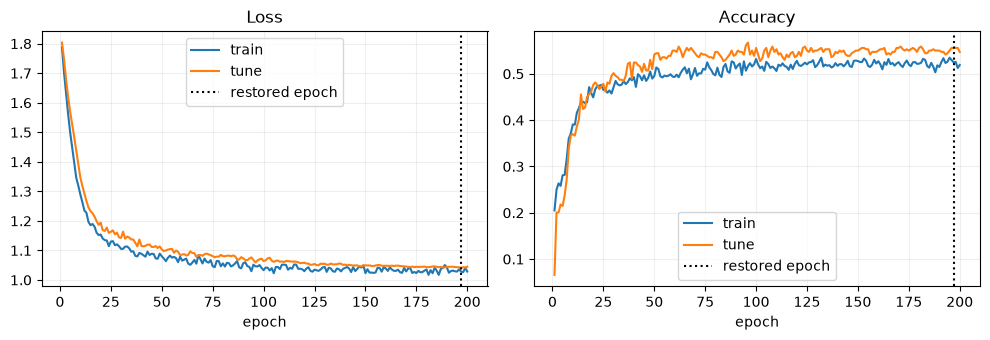

In [56]:
baseline_history_summary = analyze_training_history(baseline_history, diagnose_fit=True)

### 3.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.75      0.56        36
         1pM       0.74      0.45      0.56        78
       2.5pM       0.52      0.50      0.51        66
         5pM       0.46      0.48      0.47        62
        25pM       0.64      0.49      0.55        72
       100pM       0.58      0.97      0.72        35

    accuracy                           0.56       349
   macro avg       0.57      0.61      0.56       349
weighted avg       0.58      0.56      0.55       349



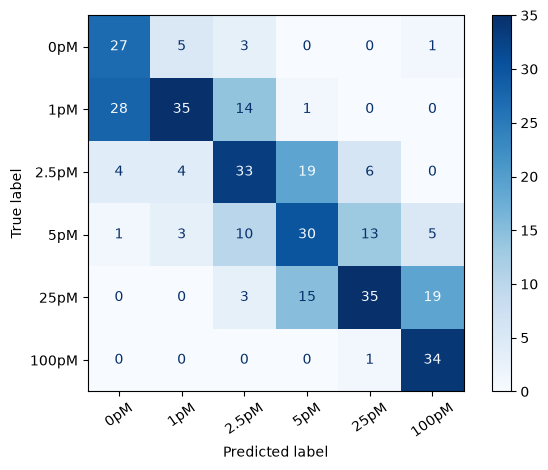

In [57]:
baseline_tune_metrics = evaluate_tune(baseline_model)

### 3.5 Saving artifacts

In [58]:
baseline_reloaded, baseline_artifacts = save_and_verify("cnn_baseline", baseline_model, baseline_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/metadata.json'))
reloaded cnn at best epoch 197


<a id="wide-cnn"></a>
## 4. Wide CNN

The high-capacity anchor uses four wider conventional blocks. Dilations remain one and residual connections remain disabled, so this comparison does not mix capacity with a different architectural principle.

### 4.1 Model generation

In [78]:
wide_model_config = {
    **BASELINE_MODEL_CONFIG,
    "channels": (32, 64, 128, 256),
    "kernel_sizes": (9, 5, 3, 3),
    "dilations": (1, 1, 1, 1),
    "hidden_dim": 128,
    "dropout": 0.0
}
wide_model, wide_parameter_count = build_model(**wide_model_config)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (32, 64, 128, 256), 'kernel_sizes': (9, 5, 3, 3), 'dilations': (1, 1, 1, 1), 'pool_size': 2, 'hidden_dim': 128, 'dropout': 0.0, 'residual': False}
trainable parameters: 168,518


### 4.2 Training

In [79]:
wide_history = fit(wide_model, PREVIOUS_SHARED_TRAINING_CONFIG)

training_config: TrainingConfig(epochs=200, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.75, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.50405, validation loss 1.69597, train accuracy 33.2%, validation accuracy 24.1%
epoch   5: train loss 0.95212, validation loss 1.46293, train accuracy 58.7%, validation accuracy 35.5%
epoch  10: train loss 0.81529, validation loss 1.04098, train accuracy 63.2%, validation accuracy 54.2%
epoch  15: train loss 0.73657, validation loss 1.12258, train accuracy 67.7%, validation accuracy 53.9%
epoch  20: train loss 0.68244, validation loss 0.91265, train accuracy 70.8%, validation accuracy 62.8%
epoch  25: train loss 0.61777, validation loss 0.91363, train accuracy 72.4%, validation accuracy 63.0%
epoch  30: train

### 4.3 History analysis

A falling train loss combined with a rising tune loss after the selected epoch is evidence that added capacity is being used to fit train-specific structure.

{'epochs_run': 57, 'best_epoch': 37, 'training_loss': 0.49338142538583407, 'tune_loss': 0.7967963597835989, 'training_accuracy': 0.782437275985663, 'tune_accuracy': 0.6389684813753582, 'training_macro_f1': 0.7817621445295543, 'tune_macro_f1': 0.64319060282117, 'accuracy_gap': 0.14346879461030482, 'macro_f1_gap': 0.13857154170838426}
Train loss improves after tune loss is best: inspect for overfitting.


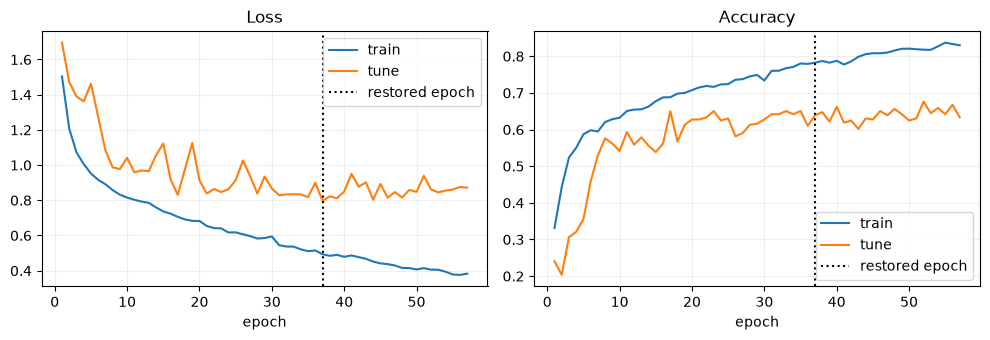

In [80]:
wide_history_summary = analyze_training_history(wide_history, diagnose_fit=True)

### 4.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.69      0.55        36
         1pM       0.63      0.59      0.61        78
       2.5pM       0.65      0.56      0.60        66
         5pM       0.60      0.48      0.54        62
        25pM       0.76      0.71      0.73        72
       100pM       0.72      0.97      0.83        35

    accuracy                           0.64       349
   macro avg       0.64      0.67      0.64       349
weighted avg       0.65      0.64      0.64       349



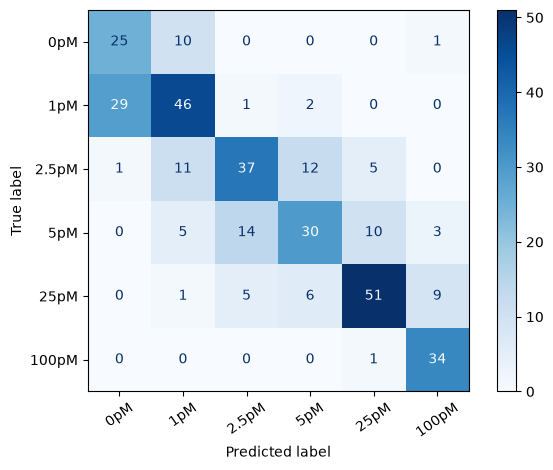

In [81]:
wide_tune_metrics = evaluate_tune(wide_model)

### 4.5 Saving artifacts

In [82]:
wide_reloaded, wide_artifacts = save_and_verify("cnn_wide", wide_model, wide_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/metadata.json'))
reloaded cnn at best epoch 37


<a id="capacity-comparison"></a>
## 5. Capacity comparison and training histories

Because training is controlled, differences here can be attributed to the capacity bundles rather than class balancing, learning rate, scheduler, or epoch budget. The restored epoch is selected by minimum tune loss.

,parameters,epochs_run,best_epoch,training_loss,tune_loss,training_accuracy,tune_accuracy,training_macro_f1,tune_macro_f1,accuracy_gap,macro_f1_gap
variant,,,,,,,,,,,
compact,686,180,180,1.2780,1.2655,0.3728,0.4842,0.3693,0.4042,-0.1115,-0.0349
baseline,11462,200,197,1.0280,1.0414,0.5247,0.5559,0.5303,0.5635,-0.0311,-0.0332
wide,168518,57,37,0.4934,0.7968,0.7824,0.6390,0.7818,0.6432,0.1435,0.1386


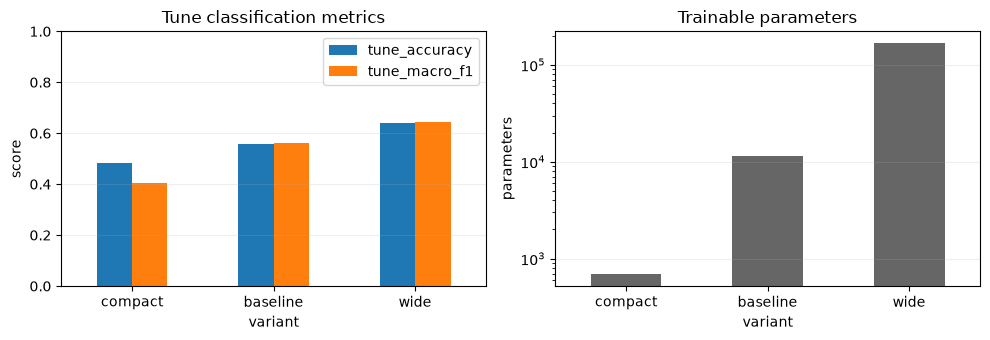

In [83]:
capacity_comparison = pd.DataFrame([
    {"variant": "compact", "parameters": compact_parameter_count,
     **compact_history_summary, **compact_tune_metrics},
    {"variant": "baseline", "parameters": baseline_parameter_count,
     **baseline_history_summary, **baseline_tune_metrics},
    {"variant": "wide", "parameters": wide_parameter_count,
     **wide_history_summary, **wide_tune_metrics},
]).set_index("variant")
display(capacity_comparison.round(4))

figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
capacity_comparison[["tune_accuracy", "tune_macro_f1"]].plot.bar(
    ax=axes[0], ylim=(0, 1), rot=0,
)
axes[0].set(title="Tune classification metrics", ylabel="score")
capacity_comparison["parameters"].plot.bar(ax=axes[1], color="0.4", rot=0)
axes[1].set(title="Trainable parameters", ylabel="parameters")
axes[1].set_yscale("log")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

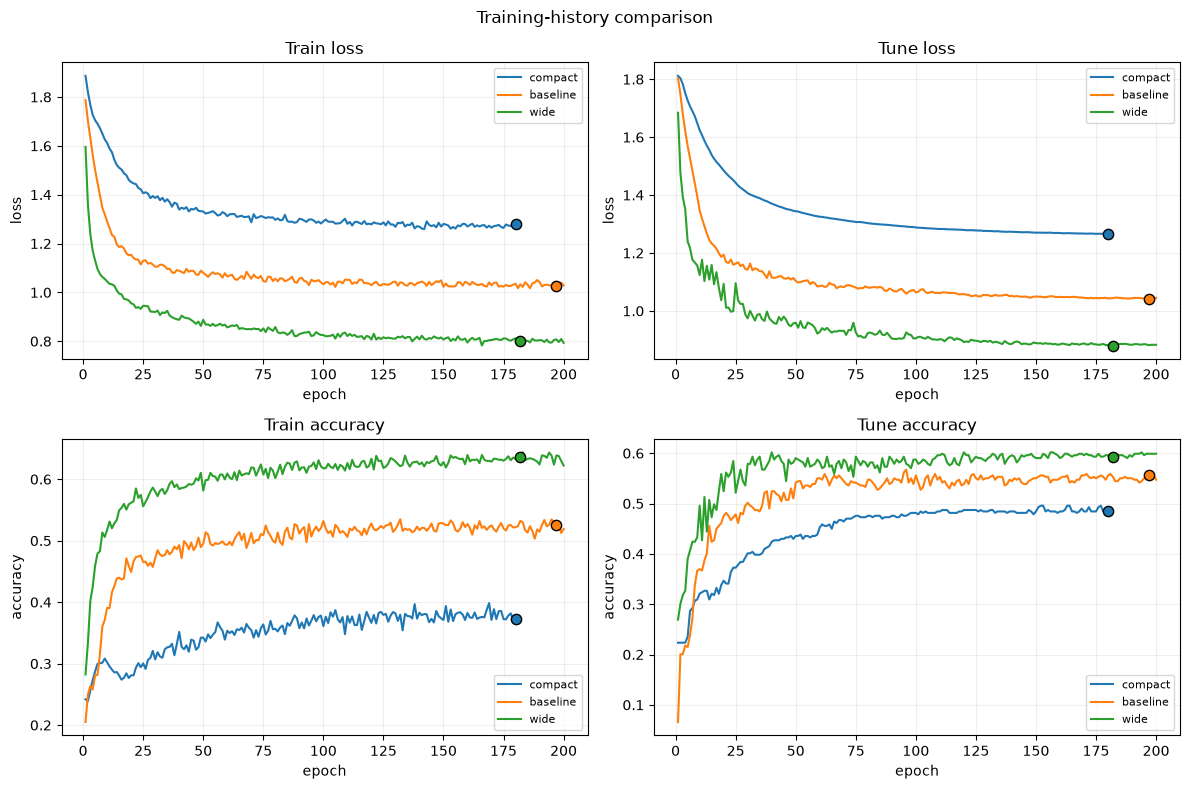

In [77]:
capacity_history_figure = plot_history_comparison({
    "compact": compact_history,
    "baseline": baseline_history,
    "wide": wide_history,
})

## Controlled ablation design

The reference occurs once. Every other specification changes one factor and is trained with the same three seeds. This is an effect study, not a hyperparameter search: no trial is selected from a lucky single run. Optuna and experiment tracking belong to the extended-CNN workflow, not this notebook.

In [84]:
def training_ablation(name, **changes):
    return AblationSpec(
        name=f"training/{name}", model_config=BASELINE_MODEL_CONFIG,
        training_config=replace(PREVIOUS_SHARED_TRAINING_CONFIG, **changes),
        random_seeds=ABLATION_SEEDS,
    )


def model_ablation(name, **changes):
    return AblationSpec(
        name=f"model/{name}",
        model_config={**BASELINE_MODEL_CONFIG, **changes},
        training_config=PREVIOUS_SHARED_TRAINING_CONFIG,
        random_seeds=ABLATION_SEEDS,
    )


reference_spec = AblationSpec(
    name="reference", model_config=BASELINE_MODEL_CONFIG,
    training_config=PREVIOUS_SHARED_TRAINING_CONFIG, random_seeds=ABLATION_SEEDS,
)
training_specs = (
    training_ablation("learning_rate=2e-4", learning_rate=2e-4),
    training_ablation("learning_rate=1.5e-3", learning_rate=1.5e-3),
    training_ablation("weight_decay=0", weight_decay=0.0),
    training_ablation("weight_decay=2e-3", weight_decay=2e-3),
    training_ablation("scheduler=constant", scheduler_strategy="none", warmup_epochs=0),
    training_ablation("scheduler=cosine", scheduler_strategy="cosine", warmup_epochs=0),
    training_ablation("scheduler=warmup_cosine", scheduler_strategy="warmup_cosine", warmup_epochs=8),
    training_ablation("class_balance=none", class_balance_strategy="none"),
    training_ablation("class_balance=balanced_sampler", class_balance_strategy="balanced_sampler"),
    training_ablation("batch_size=128", batch_size=128),
    training_ablation("batch_size=512", batch_size=512),
    training_ablation("gradient_clipping=off", gradient_clip_norm=None),
)
model_specs = (
    model_ablation("width=narrow", channels=(8, 16, 32)),
    model_ablation("width=wide", channels=(32, 64, 128)),
    model_ablation("depth=2", channels=(16, 32), kernel_sizes=(9, 5), dilations=(1, 1)),
    model_ablation("depth=4", channels=(16, 32, 64, 128), kernel_sizes=(9, 5, 3, 3), dilations=(1, 1, 1, 1)),
    model_ablation("kernels=local", kernel_sizes=(3, 3, 3)),
    model_ablation("kernels=broad", kernel_sizes=(15, 9, 5)),
    model_ablation("dilation=progressive", dilations=(1, 2, 4)),
    model_ablation("residual=on", residual=True),
    model_ablation("dropout=0", dropout=0.0),
    model_ablation("dropout=0.5", dropout=0.5),
    model_ablation("pool_size=4", pool_size=4),
)
all_ablation_specs = (reference_spec, *training_specs, *model_specs)
print(f"{len(all_ablation_specs)} configurations × {len(ABLATION_SEEDS)} seeds")

24 configurations × 3 seeds


In [85]:
RUN_ABLATIONS = True
if RUN_ABLATIONS:
    ablation_results, ablation_runs = run_ablations(
        all_ablation_specs, model_type=CNNClassifier,
        training_fold=train_fold, tuning_fold=tune_fold,
        preprocessor=preprocessor, device=device,
    )
    ablation_runs = add_paired_reference_deltas(
        ablation_runs, reference_name="reference",
    )
    ablation_summary = summarize_ablations(ablation_runs)
    ablation_output = save_ablation_study(
        artifact_dir_for("ablations") / "cnn",
        results=ablation_results, frame=ablation_runs, summary=ablation_summary,
    )
    print(f"Saved ablation tables, configs, and histories to {ablation_output}")

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (16, 32, 64), 'kernel_sizes': (9, 5, 3), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 32, 'dropout': 0.3, 'residual': False}
trainable parameters: 11,462
training_config: TrainingConfig(epochs=200, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.75, scheduler_strategy='step', warmup_epochs=0, warmup_start_factor=0.1, minimum_learning_rate=1e-06, patience=20, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.78757, validation loss 1.80352, train accuracy 20.5%, validation accuracy 6.6%
epoch   5: train loss 1.50021, validation loss 1.56988, train accuracy 28.1%, validation accuracy 21.5%
epoch  10: train loss 1.29013, validation loss 1.34769, train accuracy 39.0%, validation accuracy 37.0%
epoch  15: train loss 1.18556, validation loss 1.23224, train accuracy 44.1%, validation accuracy 42

<a id="training-ablations"></a>
## 6. Training-parameter ablations

Learning rate, weight decay, scheduler, class balancing, batch size, and gradient clipping are varied independently. Bars summarize seeds; black points retain individual runs. Paired delta is the most direct effect estimate because it subtracts the reference with the same seed.

,runs,failed_runs,tune_loss_mean,tune_loss_std,tune_accuracy_mean,tune_accuracy_std,tune_macro_f1_mean,tune_macro_f1_std,macro_f1_delta_mean,macro_f1_delta_std,macro_f1_gap_mean,best_epoch_mean,best_epoch_std,convergence_epoch_95_mean,post_best_degradation_mean,tune_loss_roughness_mean,duration_seconds_mean
name,,,,,,,,,,,,,,,,,
training/scheduler=constant,3,0,0.9802,0.0219,0.5740,0.0135,0.5698,0.0204,0.0037,0.0142,-0.0159,108.3333,24.7857,78.6667,0.0165,0.0226,7.7932
training/class_balance=balanced_sampler,3,0,1.0287,0.0111,0.5616,0.0125,0.5667,0.0144,0.0006,0.0128,0.0012,180.6667,20.5994,65.6667,0.0018,0.0092,13.4792
reference,3,0,1.0415,0.0187,0.5606,0.0165,0.5661,0.0182,0.0000,0.0000,-0.0294,126.0000,26.1534,61.3333,0.0054,0.0079,7.3762
training/weight_decay=2e-3,3,0,1.0413,0.0186,0.5568,0.0132,0.5625,0.0146,-0.0035,0.0037,-0.0265,126.0000,26.1534,60.0000,0.0055,0.0080,7.2304
training/weight_decay=0,3,0,1.0388,0.0127,0.5549,0.0101,0.5614,0.0122,-0.0046,0.0076,-0.0290,151.3333,42.4774,64.0000,0.0032,0.0074,8.2417
training/scheduler=warmup_cosine,3,0,1.0034,0.0261,0.5578,0.0044,0.5607,0.0027,-0.0053,0.0171,-0.0219,134.6667,58.5947,70.6667,0.0120,0.0150,10.5699
training/gradient_clipping=off,3,0,1.0212,0.0100,0.5540,0.0116,0.5602,0.0124,-0.0059,0.0068,-0.0215,176.6667,35.2184,68.6667,0.0022,0.0072,12.2186
training/scheduler=cosine,3,0,1.0047,0.0170,0.5568,0.0060,0.5585,0.0098,-0.0076,0.0231,-0.0180,99.6667,29.2803,64.6667,0.0221,0.0184,8.4334
training/batch_size=512,3,0,1.0769,0.0192,0.5521,0.0060,0.5584,0.0067,-0.0076,0.0171,-0.0406,182.6667,20.5264,76.6667,0.0012,0.0030,9.8073


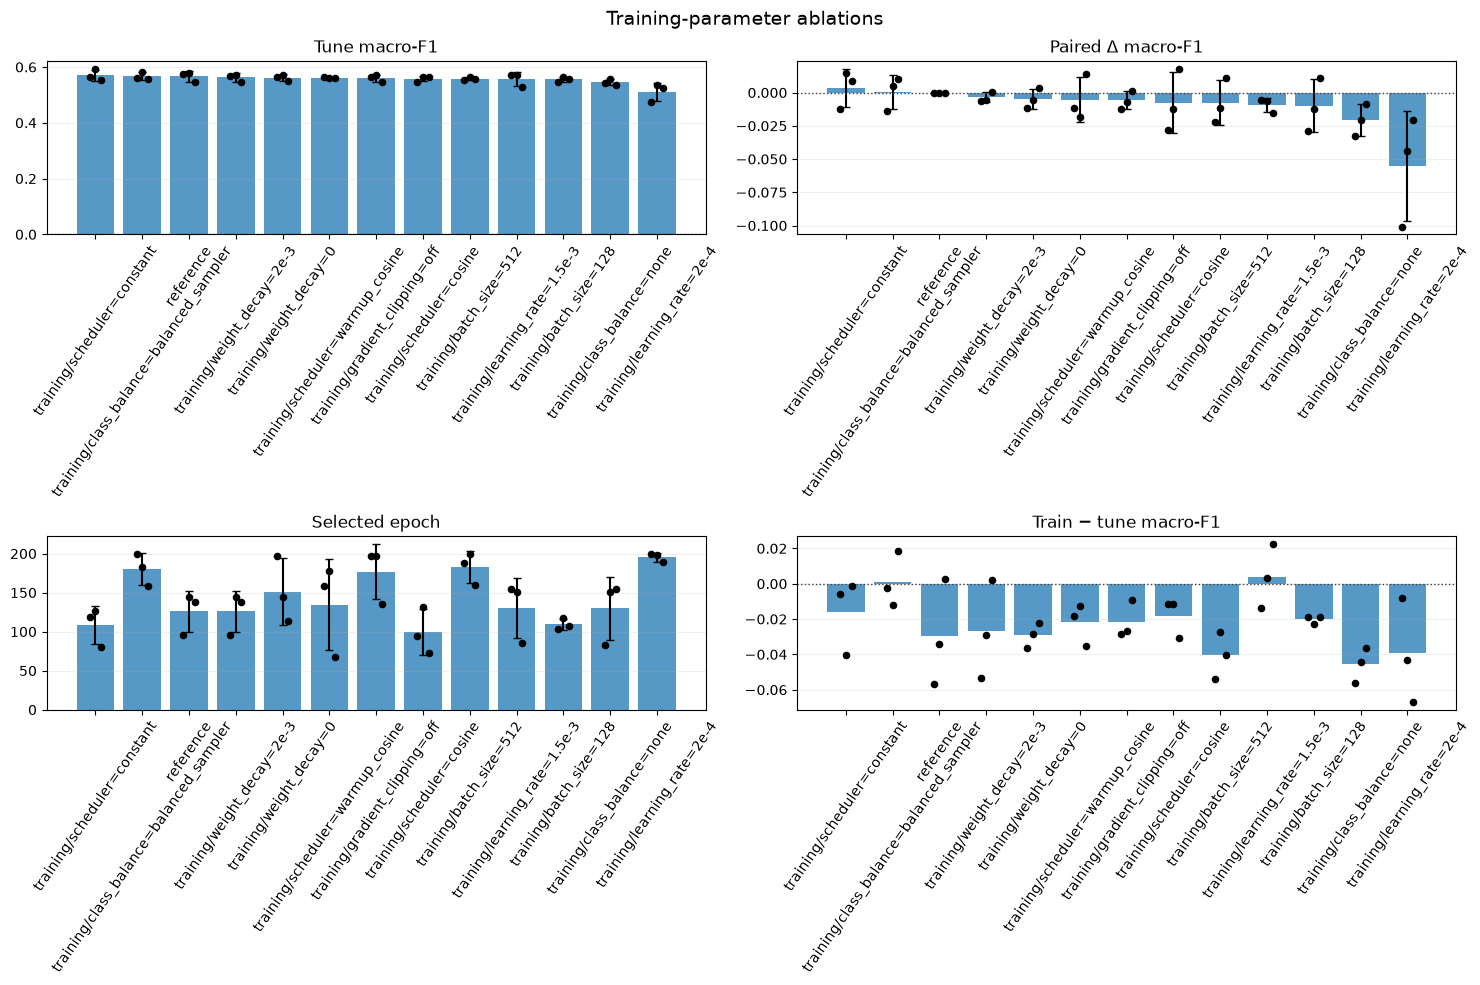

In [86]:
training_names = ["reference", *[spec.name for spec in training_specs]]
training_runs = ablation_runs[ablation_runs["name"].isin(training_names)].copy()
training_summary = ablation_summary.loc[training_names].sort_values(
    "macro_f1_delta_mean", ascending=False,
)
display(training_summary.round(4))
training_diagnostics = plot_ablation_diagnostics(
    training_runs, training_summary, title="Training-parameter ablations",
)

<a id="model-ablations"></a>
## 7. Model-parameter ablations

Width, depth, kernel range, dilation, residual connections, dropout, and pooling are changed independently while the complete training configuration stays fixed. This separates architectural effects that were previously mixed into the wide model.

In [ ]:
model_names = ["reference", *[spec.name for spec in model_specs]]
model_runs = ablation_runs[ablation_runs["name"].isin(model_names)].copy()
model_summary = ablation_summary.loc[model_names].sort_values(
    "macro_f1_delta_mean", ascending=False,
)
display(model_summary.round(4))
model_diagnostics = plot_ablation_diagnostics(
    model_runs, model_summary, title="Model-parameter ablations",
)

<a id="stability-diagnosis"></a>
## 8. Stability, convergence, and fit diagnosis

The labels below are transparent heuristics, not statistical tests. **Underfitting** means train and tune macro-F1 remain low together. **Overfitting** requires both a positive train–tune gap and tune-loss degradation after its minimum while train loss continues to improve. **Instability** is indicated by failed runs, high seed variance, or rough tune-loss curves. **Slow convergence** means reaching 95% of the eventual loss improvement takes most of the available training.

In [ ]:
def diagnose_ablation(row):
    if row["failed_runs"] > 0 or row["tune_macro_f1_std"] > 0.05:
        return "unstable"
    if row["tune_macro_f1_mean"] < 0.50 and row["macro_f1_gap_mean"] < 0.10:
        return "underfitting"
    if row["macro_f1_gap_mean"] > 0.10 and row["post_best_degradation_mean"] > 0.02:
        return "overfitting risk"
    if row["convergence_epoch_95_mean"] > 0.75 * SHARED_TRAINING_CONFIG.epochs:
        return "slow convergence"
    return "stable / mixed evidence"


diagnostic_table = ablation_summary.copy()
diagnostic_table["diagnosis"] = diagnostic_table.apply(diagnose_ablation, axis=1)
display(diagnostic_table[[
    "tune_macro_f1_mean", "tune_macro_f1_std",
    "macro_f1_delta_mean", "macro_f1_gap_mean",
    "convergence_epoch_95_mean", "post_best_degradation_mean",
    "tune_loss_roughness_mean", "failed_runs", "diagnosis",
]].round(4))

In [ ]:
def selected_histories(results, summary, prefix):
    candidates = summary.drop(index="reference")
    selected_names = [
        "reference",
        candidates["macro_f1_delta_mean"].idxmax(),
        candidates["macro_f1_delta_mean"].idxmin(),
    ]
    histories = {}
    for name in selected_names:
        result = next(
            item for item in results
            if item.name == name and item.random_seed == RANDOM_SEED and item.history is not None
        )
        histories[name] = result.history
    print(f"{prefix}: reference, strongest mean gain, strongest mean loss")
    return histories


training_selected_history_figure = plot_history_comparison(
    selected_histories(ablation_results, training_summary, "training")
)
model_selected_history_figure = plot_history_comparison(
    selected_histories(ablation_results, model_summary, "model")
)

<a id="conclusions"></a>
## 9. Conclusions: what should be optimized first?

A robust gain is defined conservatively as the paired mean improvement minus one standard deviation. This rewards improvements that repeat across seeds. The comparison below answers prioritization for this dataset and budget; it is not a universal statement that training or architecture is always more important.

In [ ]:
def strongest_robust_effect(summary):
    candidates = summary.drop(index="reference").copy()
    candidates["robust_gain"] = (
        candidates["macro_f1_delta_mean"]
        - candidates["macro_f1_delta_std"].fillna(0)
    )
    return candidates.loc[candidates["robust_gain"].idxmax()]


best_training_name = strongest_robust_effect(training_summary).name
best_model_name = strongest_robust_effect(model_summary).name
best_training = strongest_robust_effect(training_summary)
best_model = strongest_robust_effect(model_summary)
priority = "training parameters" if best_training["robust_gain"] >= best_model["robust_gain"] else "model parameters"

conclusion = pd.DataFrame([
    {"block": "training", "best_factor": best_training_name,
     "paired_gain_mean": best_training["macro_f1_delta_mean"],
     "paired_gain_std": best_training["macro_f1_delta_std"],
     "robust_gain": best_training["robust_gain"],
     "diagnosis": diagnostic_table.loc[best_training_name, "diagnosis"]},
    {"block": "model", "best_factor": best_model_name,
     "paired_gain_mean": best_model["macro_f1_delta_mean"],
     "paired_gain_std": best_model["macro_f1_delta_std"],
     "robust_gain": best_model["robust_gain"],
     "diagnosis": diagnostic_table.loc[best_model_name, "diagnosis"]},
])
display(conclusion.round(4))
print(f"Optimize {priority} first under this experimental budget.")
print("Prefer paired effects with low seed variance; inspect the diagnosis table and selected histories before accepting the recommendation.")